In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None  # default='warn'

## Data understanding

In [2]:
# loading the dataset:
df = pd.read_csv('netflix_titles.csv') # https://www.kaggle.com/datasets/shivamb/netflix-shows

In [3]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [4]:
# shape of the dataframe:
df.shape

(8807, 12)

In [5]:
# the info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
# number of tv shows and movies:
df['type'].value_counts()

Movie      6131
TV Show    2676
Name: type, dtype: int64

In [8]:
# average release year:
df['release_year'].mean()

2014.1801975701146

## data cleaning

In [9]:
# convert date added into actual dates:
df['date_added'] = pd.to_datetime(df['date_added'])
df['date_added'].dtype

dtype('<M8[ns]')

In [10]:
df['date_added'].dt.year
df['date_added'].dt.month.value_counts()
df['date_added'].dt.day.value_counts()


1.0     2212
15.0     687
2.0      325
16.0     289
31.0     274
20.0     249
19.0     243
5.0      231
22.0     230
10.0     214
30.0     210
6.0      210
18.0     207
26.0     206
8.0      201
14.0     198
25.0     197
27.0     195
7.0      194
21.0     193
28.0     190
23.0     184
12.0     181
17.0     180
4.0      175
13.0     175
24.0     159
3.0      151
11.0     149
9.0      147
29.0     141
Name: date_added, dtype: int64

In [239]:
# cleaning the minutes for the movie rows:
df[df.type == "Movie"]['duration']

0        90
6        91
7       125
9       104
12      127
       ... 
8801     96
8802    158
8804     88
8805     88
8806    111
Name: duration, Length: 6131, dtype: Int64

In [13]:
# cleaned the data and converted the values to int:
temp = df['duration']
df = df.drop('duration', axis=1)
df['duration']=temp.str.extract('(\d+)').astype("Int64").iloc[:,0]
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2


In [14]:
# stats on movies:
df[df.type == 'Movie']['duration'].describe()

count       6128.0
mean     99.577187
std      28.290593
min            3.0
25%           87.0
50%           98.0
75%          114.0
max          312.0
Name: duration, dtype: Float64

In [15]:
# stats of tv series:
df[df.type == 'TV Show']['duration'].describe()

count      2676.0
mean     1.764948
std      1.582752
min           1.0
25%           1.0
50%           1.0
75%           2.0
max          17.0
Name: duration, dtype: Float64

## Exploratory Data Analysis (EDA)

### Movies vs TV Shows

<Axes: ylabel='type'>

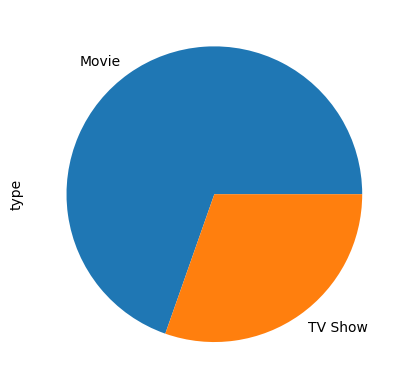

In [16]:
df['type'].value_counts().plot(kind='pie')
# This shows that there are more movies than TV Shows on Netflix.

### Top 10 countries with most Netflix content

<Axes: >

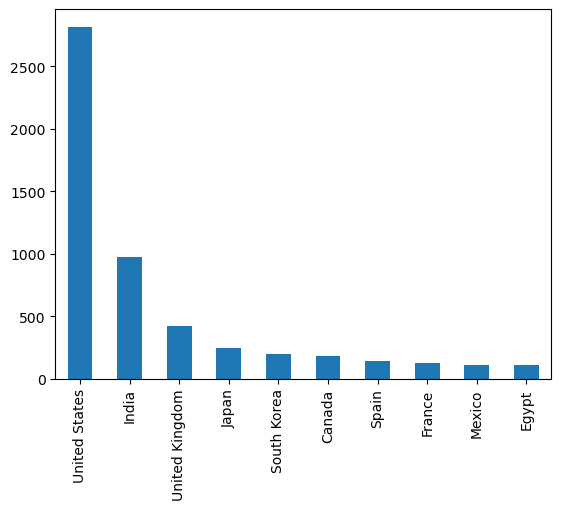

In [240]:
df['country'].value_counts(ascending=False).head(10).plot(kind='bar')
# the countries with most content on Netflix are US, India and UK

### number of titles added per year

<Axes: >

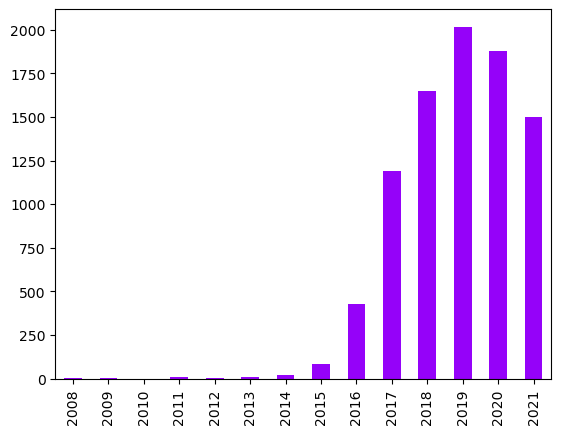

In [244]:
df['date_added'].dt.year.astype("Int64").value_counts().sort_index().plot(kind='bar', color='#9502f9')
# most titles have been added after 2016.

### top n geners

<Axes: >

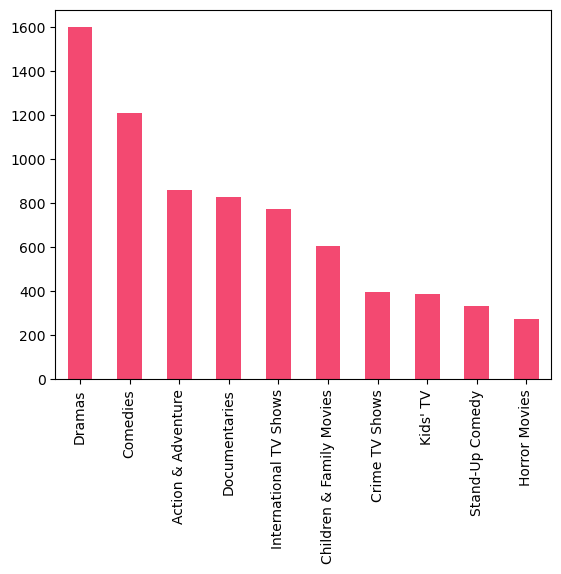

In [19]:
def filter_content(row):
    if "," in row:
        stripped = [s.strip() for s in row.split(',')]
        return list([stripped[0]])
    else:
        return list([row])

df['genres'] = df['listed_in'].apply(filter_content)
df['genres'].explode().value_counts(ascending=False).head(10).plot(kind='bar', color="#f34971")
# most popular genres are dramas, comedies, action & adventure and documenteries. 

### most common TV ratings

<Axes: >

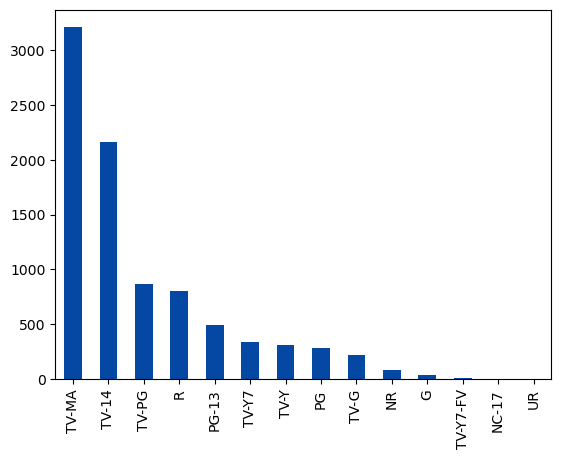

In [20]:
df['rating'].value_counts()[:-3].plot(kind="bar", color="#0448a3")
# the most common rating are TV-MA (i.e. mature audience) and TV-14 
# (unsuitable for under 14 audience).

### directors and actors that appear most

In [21]:
df['director'].value_counts().head(20)

Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Don Michael Paul          10
David Dhawan               9
Yılmaz Erdoğan             8
Lance Bangs                8
Kunle Afolayan             8
Quentin Tarantino          8
Ryan Polito                8
Troy Miller                8
Shannon Hartman            8
Fernando Ayllón            8
Name: director, dtype: int64

In [22]:
def filter_values(row):
    if "," in row:
        elements = row.split(",")
        elements = [item.strip() for item in elements]
        return elements
    else:
        return row
# actors with most appearences in movies and tv series:
df['cast'][~df['cast'].isna()].apply(filter_values).explode().value_counts().head(15)

Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Paresh Rawal        28
Amitabh Bachchan    28
Boman Irani         27
Rajesh Kava         26
Vincent Tong        26
Andrea Libman       25
Name: cast, dtype: int64

### Release_year of titles in per 10 year brackets

<Axes: >

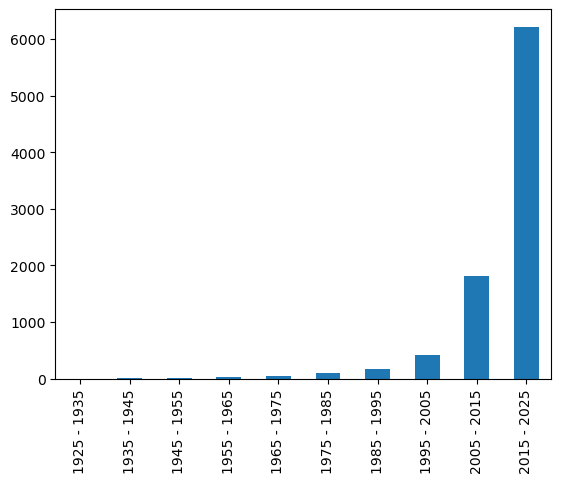

In [23]:
# temp = df[['title','release_year']].groupby('release_year').count().sort_index(ascending=True)
# temp.rename(columns = {'title':'titles'})
# temp.plot(kind='bar', xlabel='release_year', ylabel='titles')

df['release_year'].describe()

# 1925 - 1935 - 1945 - 1955 - 1965 - 1975 - 1985 - 1995 - 2005 - 2015 - 2025
conditions = [
    (df['release_year'] >= 1925) & (df['release_year'] < 1935),
    (df['release_year'] >= 1935) & (df['release_year'] < 1945),
    (df['release_year'] >= 1945) & (df['release_year'] < 1955),
    (df['release_year'] >= 1955) & (df['release_year'] < 1965),
    (df['release_year'] >= 1965) & (df['release_year'] < 1975),
    (df['release_year'] >= 1975) & (df['release_year'] < 1985),
    (df['release_year'] >= 1985) & (df['release_year'] < 1995),
    (df['release_year'] >= 1995) & (df['release_year'] < 2005),
    (df['release_year'] >= 2005) & (df['release_year'] < 2015),
    (df['release_year'] >= 2015) & (df['release_year'] < 2025),
]

tiers = ['1925 - 1935', '1935 - 1945', '1945 - 1955', '1955 - 1965', '1965 - 1975', '1975 - 1985', '1985 - 1995'
        , '1995 - 2005', '2005 - 2015', '2015 - 2025']
df['ry_tier'] = np.select(conditions, tiers)
#df[df.release_year > 2005]['release_year'].describe()
df['ry_tier'].value_counts().sort_index().plot(kind='bar')

## Deeper insights

### Countries that specialise in certain genres

In [24]:
temp = df[['title','country', 'listed_in']][(~df['country'].isna()) & (~df['listed_in'].isna())]

#temp = temp.head(30)



def filter_content(row):
    if "," in row:
        contents = row.split(",")
        contents = [item.strip().lower().title() for item in contents]
        return contents
    else:
        return row.strip().lower().title()

temp['country'] = temp['country'].apply(filter_content)
temp['listed_in'] = temp['listed_in'].apply(filter_content)
temp['listed_in']

temp.explode('country').reset_index(drop=True).explode('listed_in').groupby(['country','listed_in']).count().sort_values(['title'], ascending=[False]).head(20)
# as shown the most popular countries in terms of published content are India and the United States and the most popular genres are comdedy and drama.

title
country        listed_in                      
India          International Movies        864
United States  Dramas                      835
               Comedies                    680
India          Dramas                      662
United States  Documentaries               512
               Action & Adventure          404
               Children & Family Movies    390
               Independent Movies          390
India          Comedies                    323
United States  Thrillers                   292
               Tv Comedies                 258
               Tv Dramas                   232
United Kingdom British Tv Shows            225
United States  Romantic Movies             225
               Stand-Up Comedy             216
               Kids' Tv                    214
France         International Movies        207
United States  Horror Movies               201
United Kingdom Dramas                      197
United States  Docuseries                  192

### Investigate whether Netflix focuses more on recent or older content.

,release_year,da_year,difference
count,8783.000000,8783.000000,8783.000000
mean,2014.175453,2018.873278,4.697825
std,8.826735,1.573304,8.790808
min,1925.000000,2008.000000,0.000000
25%,2013.000000,2018.000000,0.000000
50%,2017.000000,2019.000000,1.000000
75%,2019.000000,2020.000000,5.000000
max,2021.000000,2021.000000,93.000000


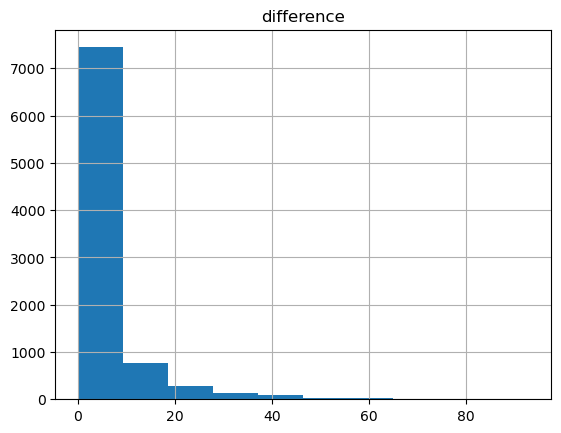

In [87]:
# temp = df[['title', 'date_added', 'release_year']]
# temp['difference'] = temp['date_added'].dt.year - temp['release_year']
temp = df[(~df['date_added'].isna()) & (~df['release_year'].isna())][['title', 'date_added', 'release_year']]


temp['da_year'] = temp['date_added'].dt.year
temp['difference'] = temp['da_year'] - temp['release_year']
temp[temp['difference'] >=0].sort_values('difference')['difference'].describe()

temp[temp['difference'] >=0].sort_values('difference').hist(column='difference')
temp[temp['difference'] >=0].sort_values('difference').describe()
# from this result we can see that the majority of the content into the platform are relatively recent

### Explore duration patterns (e.g., most common movie lengths, average number of seasons in TV shows).

In [98]:
df[df.type == "TV Show"]['duration'].describe()
# most tv series on netflix consist of a single season.

count      2676.0
mean     1.764948
std      1.582752
min           1.0
25%           1.0
50%           1.0
75%           2.0
max          17.0
Name: duration, dtype: Float64

In [99]:
df[df.type == "Movie"]['duration'].describe()
# the average duration of movies on netflix is 100 minutes; the shortest movie is 3 minutes and the longest movie is 312 minutes.

count       6128.0
mean     99.577187
std      28.290593
min            3.0
25%           87.0
50%           98.0
75%          114.0
max          312.0
Name: duration, dtype: Float64

### Identify trends over time: Are TV Shows becoming more common than Movies?

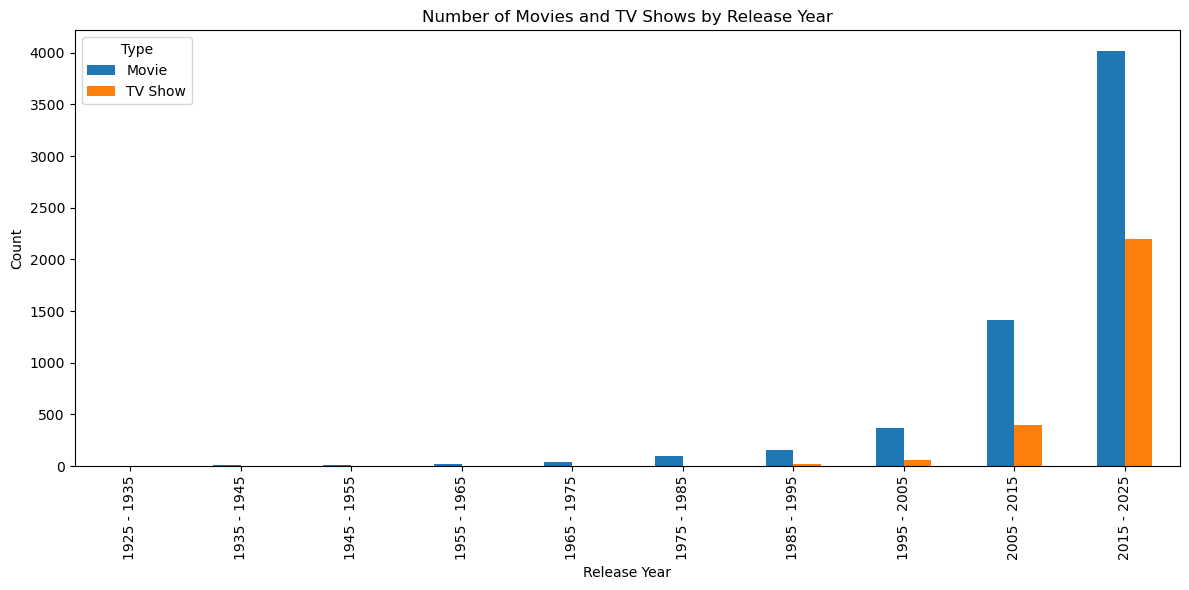

In [165]:
#df[['title','release_year', 'type']].groupby(["type",'release_year']).count()


# Group by release_year and type, then count
grouped = df.groupby(['ry_tier', 'type']).size().reset_index(name='count')

# Pivot so we can plot easily
pivot_df = grouped.pivot(index='ry_tier', columns='type', values='count').fillna(0)

# Plot
pivot_df.plot(kind='bar', figsize=(12, 6))
plt.title('Number of Movies and TV Shows by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.legend(title='Type')
plt.tight_layout()
plt.show()
# from this analysis we can see that movies have been more common on the netflix pltform.



### Movies vs TV Shows (bar chart)

<Axes: ylabel='type'>

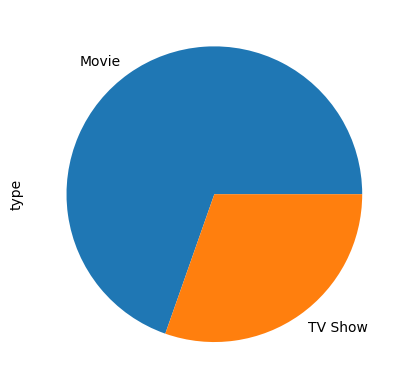

In [176]:
df['type'].value_counts().plot(kind='pie')

### Content added per year (line chart)

<Axes: >

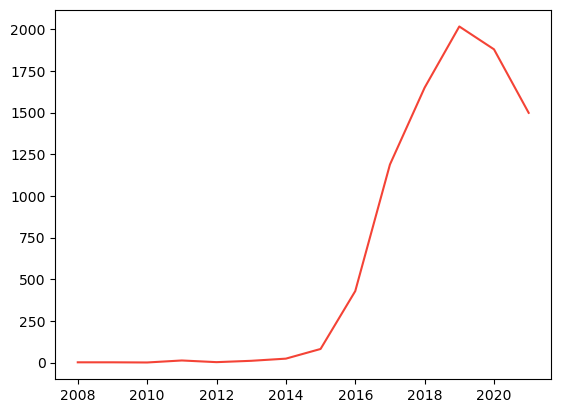

In [214]:
df['date_added'].dt.year.value_counts().sort_index().plot(kind='line', color='#f44336')

### Top countries by content (horizontal bar)

<Axes: >

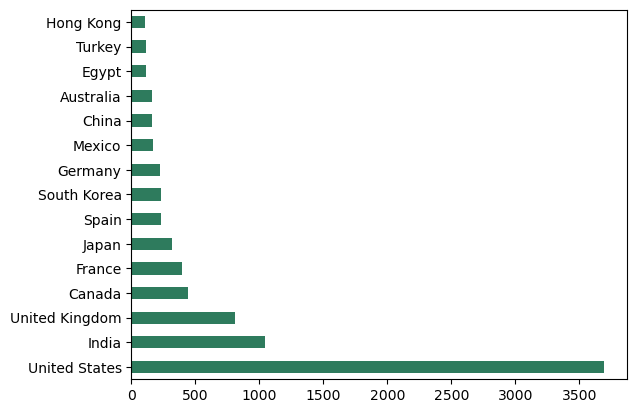

In [213]:
df[~df['country'].isna()]['country'].apply(filter_content).explode().value_counts(ascending=False).head(15).plot(kind='barh', color='#2e7b5d')

### Genre popularity (bar or word cloud)

<Axes: >

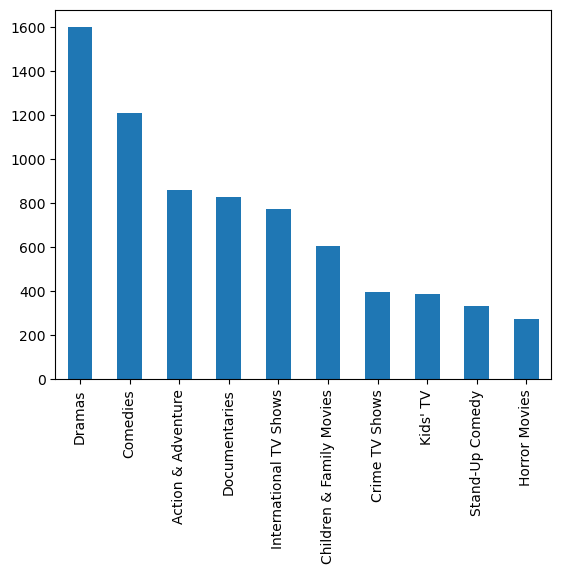

In [223]:

df['genres'].explode().value_counts().head(10).plot(kind='bar')

### Ratings distribution (pie or bar chart)

<Axes: ylabel='rating'>

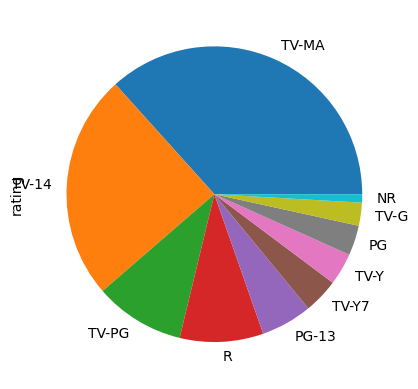

In [235]:
df['rating'].value_counts()[:-3].head(10).plot(kind='pie')